In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
import warnings
warnings.filterwarnings("ignore")

In [3]:
ruta = "../DATA/fin_mark_full_mod.csv"
df = pd.read_csv(ruta, sep=';')
import os
os.getcwd()

'c:\\Users\\hugob\\OneDrive\\Escritorio\\proyecto predicción\\trabajo_Eda\\SRC'

In [4]:
df.info()
df.shape   

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         40198 non-null  object 
 6   loan            40198 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41093 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

(41188, 21)

In [5]:
df.head(7)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,is_suscribed
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,-1,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,-1,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,-1,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,-1,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,-1,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
5,45,services,married,basic.9y,unknown,no,no,telephone,may,mon,...,1,-1,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
6,59,admin.,married,professional.course,no,no,no,telephone,may,mon,...,1,-1,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0


In [6]:
for col in df.select_dtypes(include=['number']).columns: 
    median_value = df[col].median() 
    df[col].fillna(median_value, inplace=True) 

antes, lo único que había hecho con los nulos era quitarlos, pero finalmente en vez eliminiar los nulos de las variables numéricas los sustituyo por la mediana

In [7]:
df['housing'] = df['housing'].fillna('None')
df['loan'] = df['loan'].fillna('None')

housing y loan también tenían nulos, pero al no ser variables numericas no puedo sustituir los nulos por la mediana, por lo tanto en vez de dejarlos los cambio por None

In [8]:
df.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
is_suscribed      0
dtype: int64

In [9]:
df = df.drop(df[df['marital'] == 'unknown'].index)

In [10]:
df['marital'].value_counts()

marital
married     24928
single      11568
divorced     4612
Name: count, dtype: int64

In [11]:
df = df.drop(df[df['default'] == 'unknown'].index)

In [12]:
df['default'].value_counts()


default
no     32519
yes        3
Name: count, dtype: int64

In [13]:
df = df.drop(df[df['housing'] == 'unknown'].index)

In [14]:
df['housing'].value_counts()


housing
yes     17180
no      14580
None      762
Name: count, dtype: int64

In [15]:
df = df.drop(df[df['loan'] == 'unknown'].index)

In [16]:
df['loan'].value_counts()


loan
no      26794
yes      4966
None      762
Name: count, dtype: int64

In [17]:
df = df.drop(df[df['emp.var.rate'] == 'unknown'].index)

In [18]:
df['emp.var.rate'].value_counts()


emp.var.rate
 1.4    11877
-1.8     7828
 1.1     5357
-0.1     3252
-2.9     1609
-3.4     1046
-1.7      758
-1.1      620
-3.0      165
-0.2       10
Name: count, dtype: int64

las filas desde marital hasta esta ultima estoy eliminando los valores desconocidos con el df.drop

In [19]:
df['pdays'] = df['pdays'].replace(-1, 'no_previous_contact').astype('object') 
df['is_suscribed'] = df['is_suscribed'].astype('object') 

cambio el -1 de pdays por no contacto previo para entenderlo mejor cuando lo grafique y ademas lo cambio a objeto. con is suscribed hago lo mismo, lo paso a objeto ya que estaba como numerica

In [20]:
df['is_suscribed'].value_counts() 

is_suscribed
0    28337
1     4185
Name: count, dtype: int64

cuento los valores unicos de is suscribed para saber cuantos estan suscritos y cuantos no (0 = no 1 = si) 

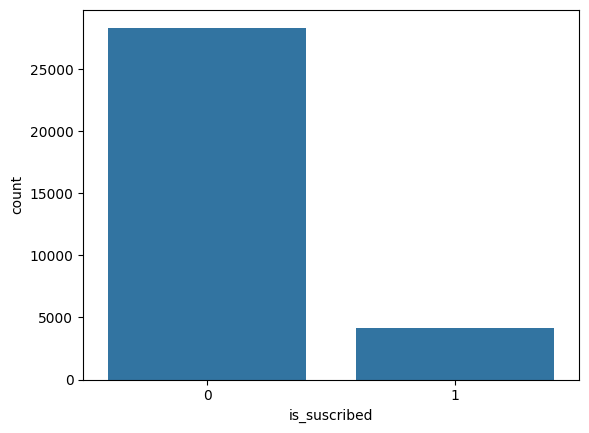

In [21]:
sns.countplot(data=df, x='is_suscribed')
plt.show()

esta celda es solo para visualizar que clientes han suscrito el deposito a plazo y cuales no lo han hecho

In [22]:
df.describe()

,age,duration,campaign,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,32522.000000,32522.000000,32522.000000,32522.000000,32522.000000,32522.000000,32522.000000,32522.000000,32522.000000
mean,39.140305,259.705584,2.519648,0.198789,-0.079491,93.525970,-40.564255,3.449794,5160.019224
std,10.476884,260.985418,2.705813,0.532451,1.616696,0.588434,4.803599,1.783320,75.802911
min,17.000000,0.000000,1.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,31.000000,103.000000,1.000000,0.000000,-1.800000,93.075000,-42.700000,1.313000,5099.100000
50%,37.000000,181.000000,2.000000,0.000000,1.100000,93.444000,-41.800000,4.856000,5191.000000
75%,46.000000,321.000000,3.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,95.000000,4918.000000,43.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [23]:
categorical_vars = df.select_dtypes(include=['object']).columns.tolist()
numerical_vars = df.select_dtypes(include=['number']).columns.tolist()

print("Variables categóricas:", categorical_vars)
print("Variables numéricas:", numerical_vars)

Variables categóricas: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'pdays', 'poutcome', 'is_suscribed']
Variables numéricas: ['age', 'duration', 'campaign', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']


In [24]:
for col in numerical_vars:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
    df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])

En este codigo lo que he tratado es la eliminación de outliers, ya que analizando los graficos de las variables que se visualizaran posteriormente habia ciertos valores atipicos. lo que es la elimminacion de outliers en si son las 5 primeras lineas del bucle. las dos ultimas son para que cuando haga los graficos de las variables que tenian outliers tengan unos limites donde estaban los outliers

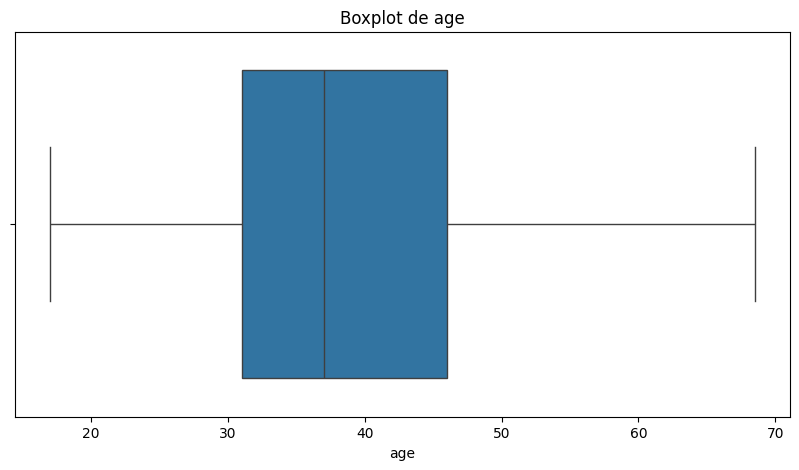

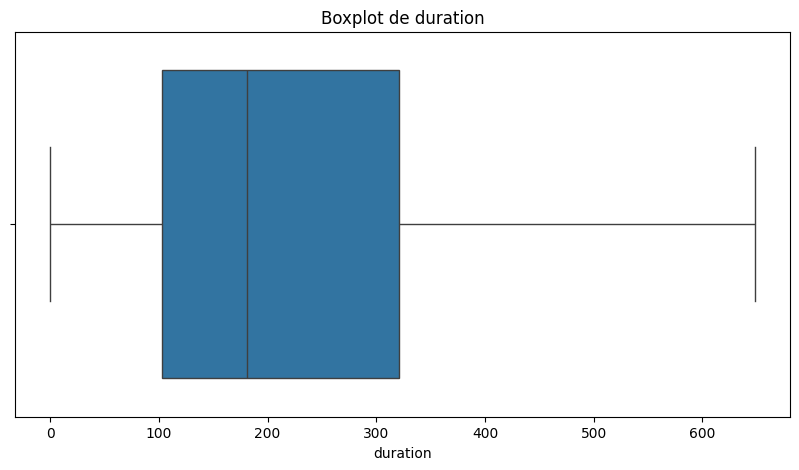

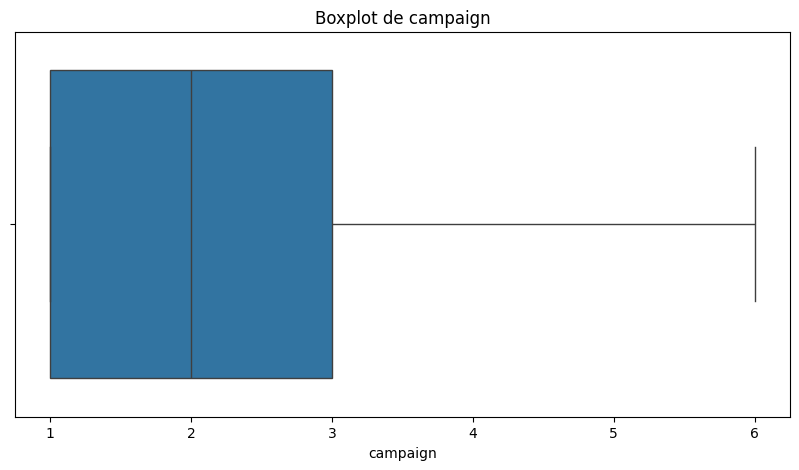

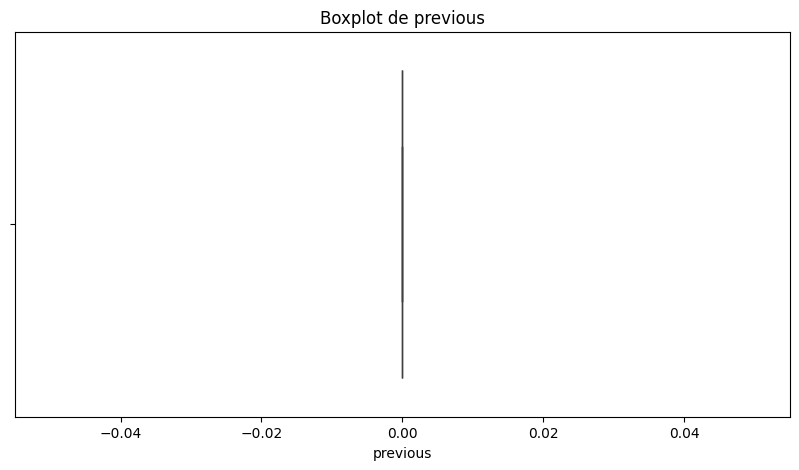

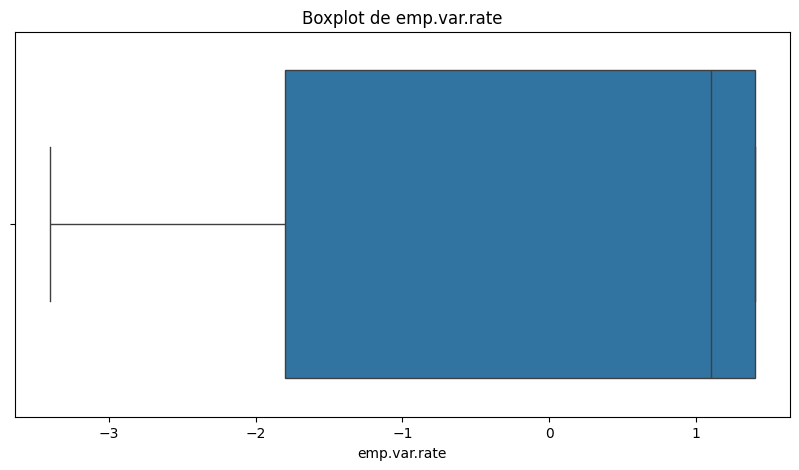

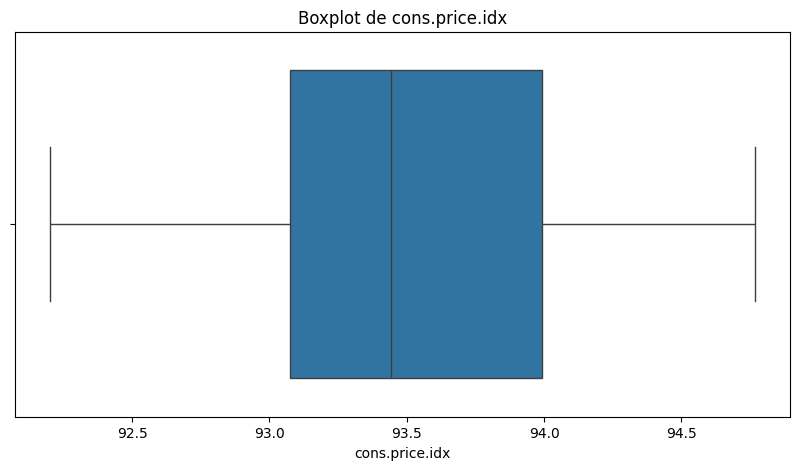

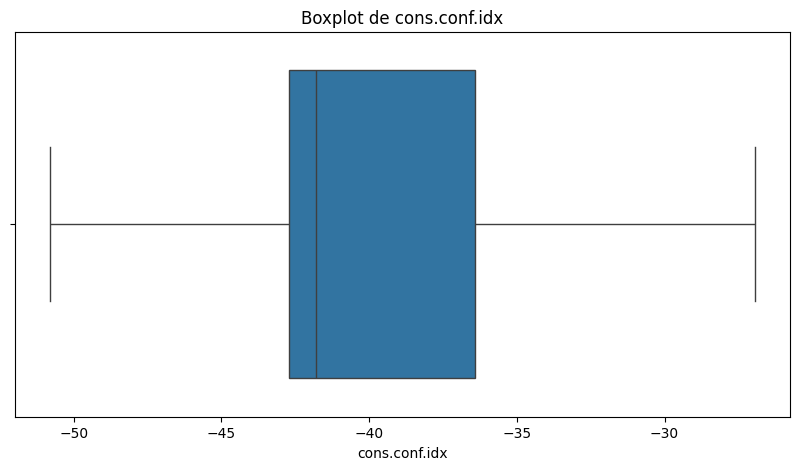

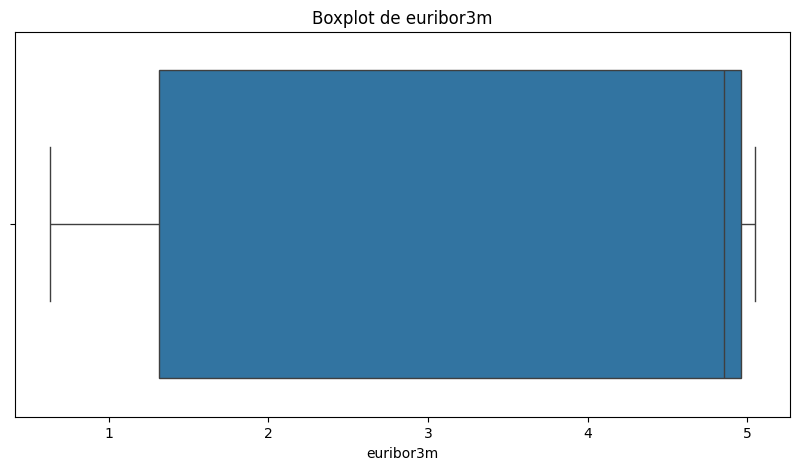

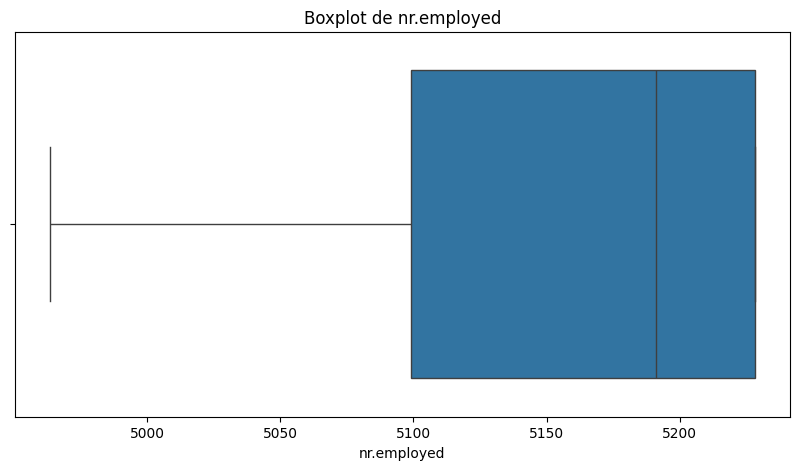

In [25]:
for col in numerical_vars:
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=df, x=col)
    plt.title(f"Boxplot de {col}")
    plt.show()

separar categoricas y numericas

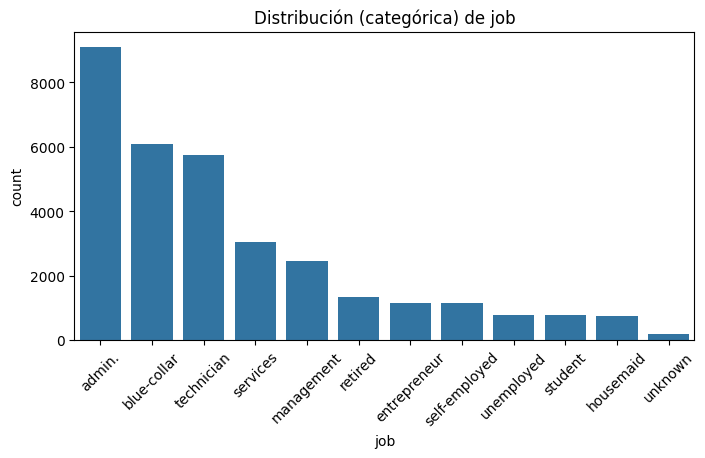

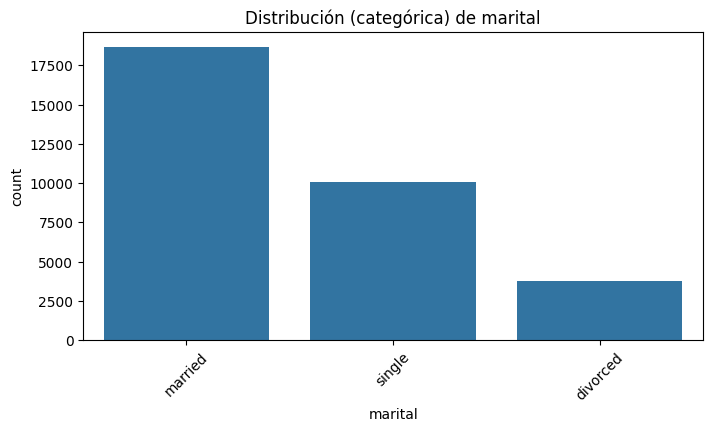

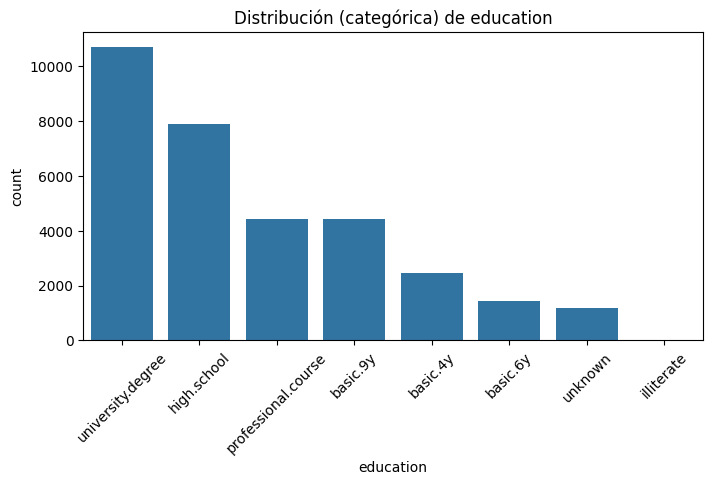

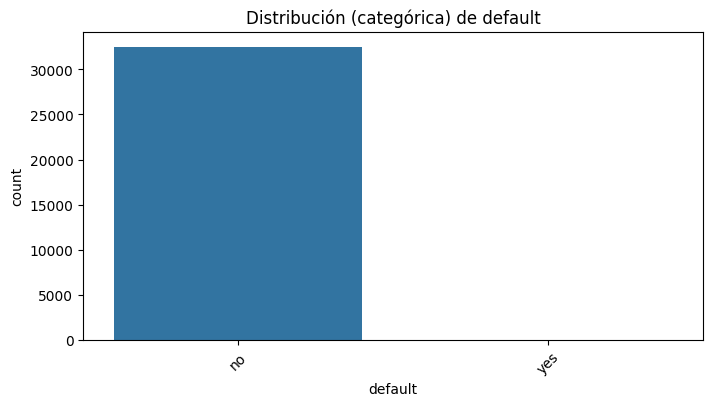

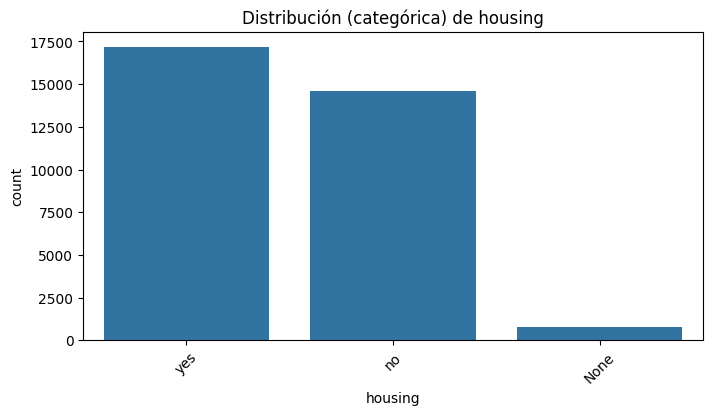

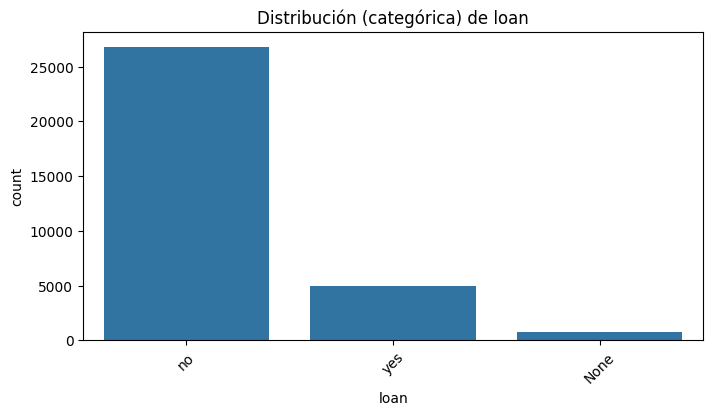

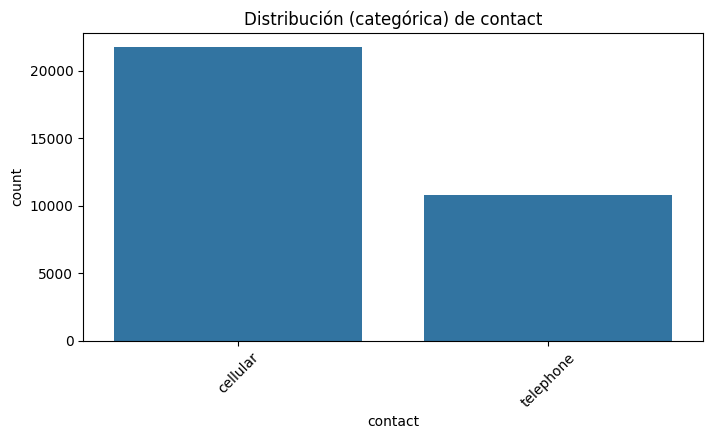

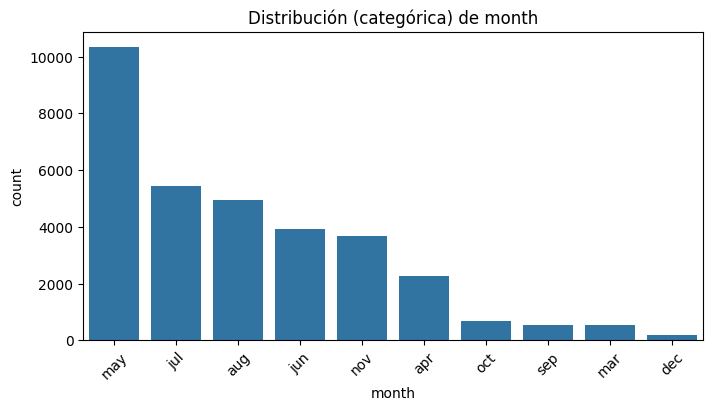

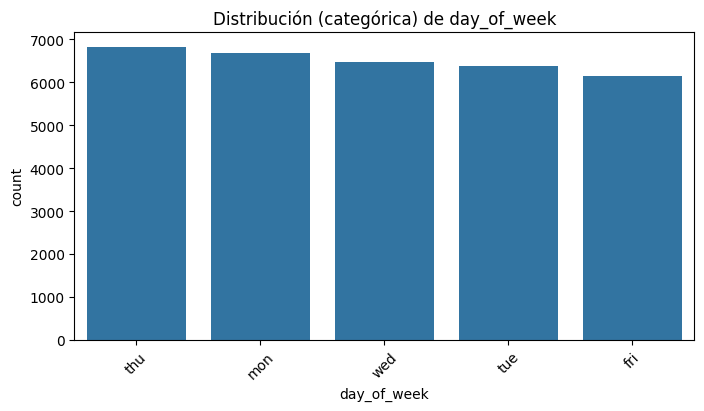

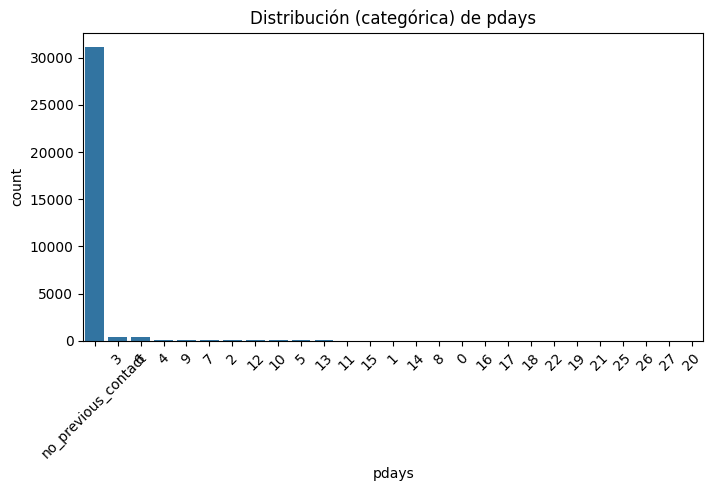

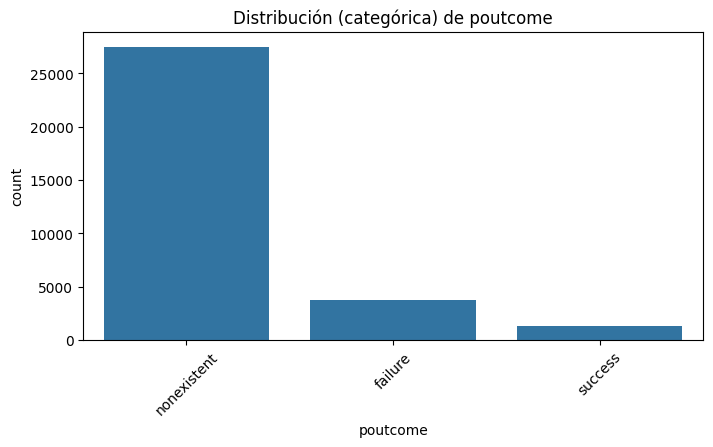

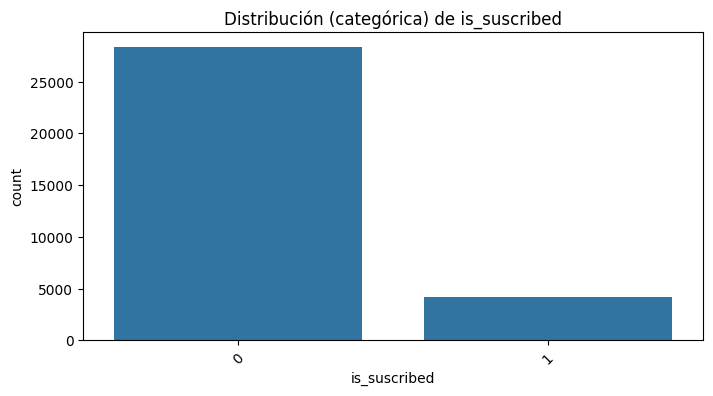

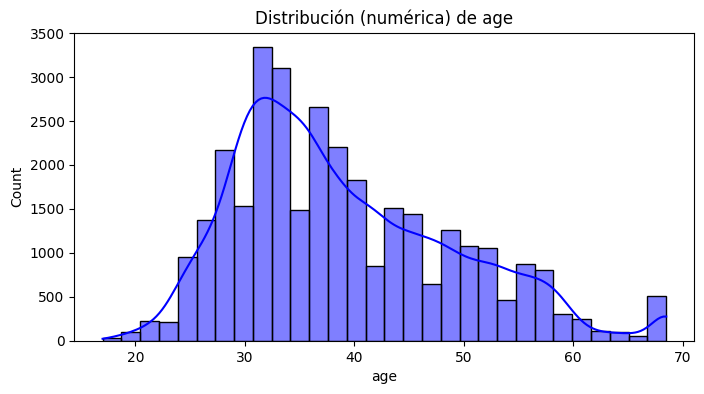

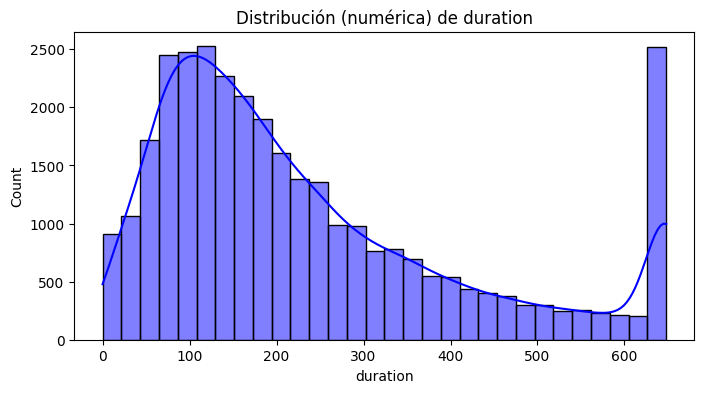

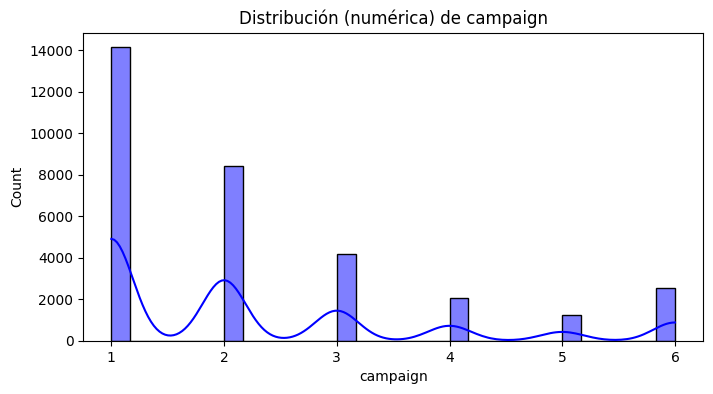

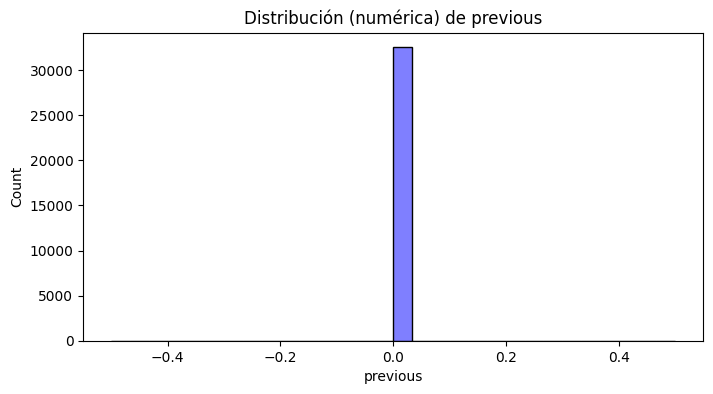

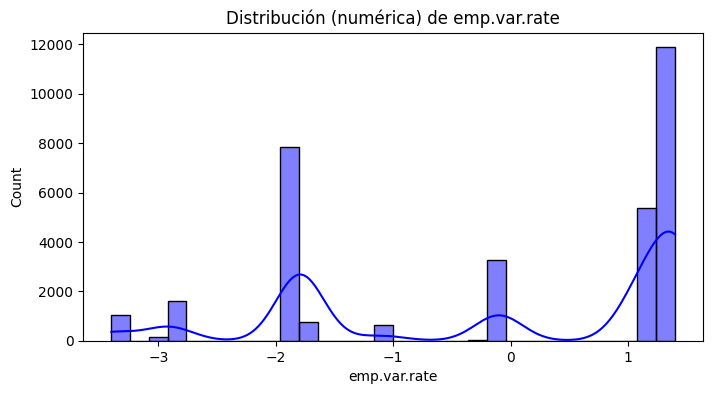

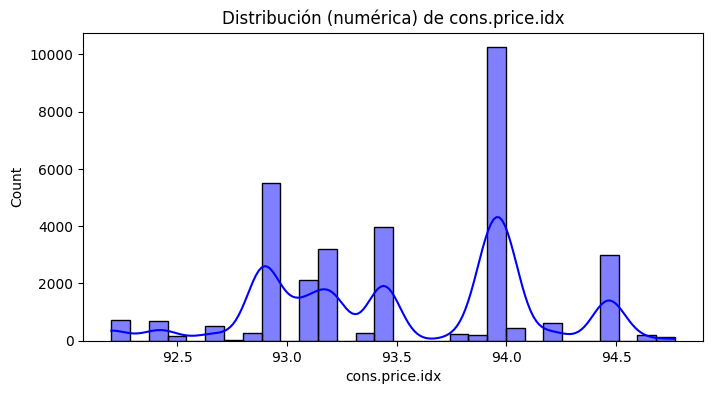

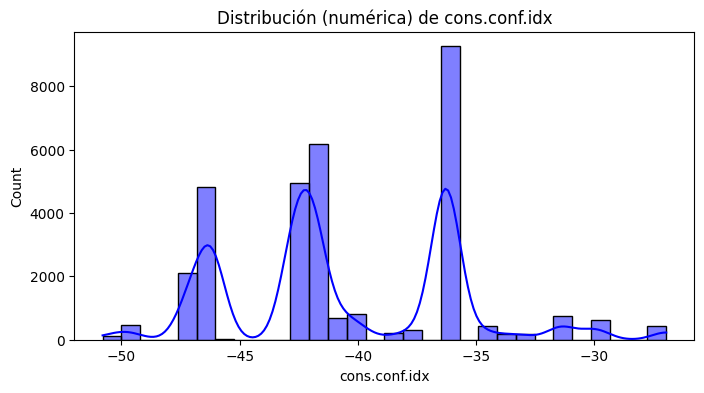

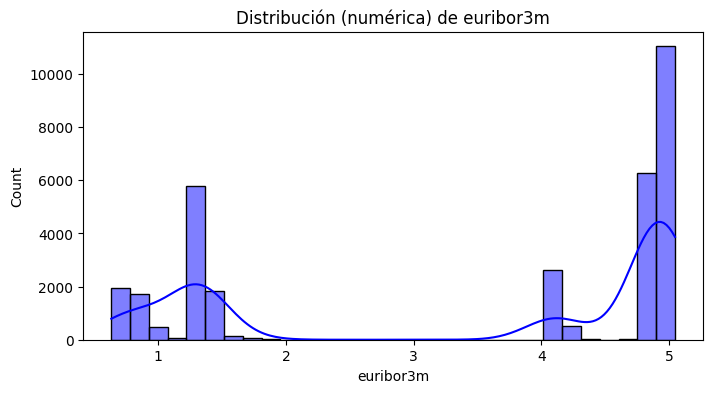

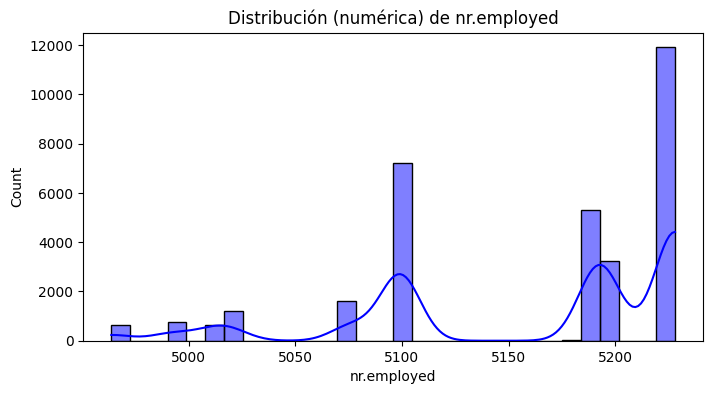

In [26]:
for col in categorical_vars: 
    plt.figure(figsize=(8, 4)) 
    sns.countplot(data=df, x=col, order=df[col].value_counts().index) 
    plt.title(f"Distribución (categórica) de {col}") 
    plt.xticks(rotation=45) 
    plt.show() 

for col in numerical_vars: 
    plt.figure(figsize=(8, 4)) 
    sns.histplot(data=df, x=col, kde=True, color="blue", bins=30) 
    plt.title(f"Distribución (numérica) de {col}") 
    plt.show() 

el bucle for recorre toda las variables categoricas y numericas, el seabron se utiliza para hacer el gráfico(en este caso lo he hecho de barras) el .figure es para establecer un tamaño para cada grafico y el xticks es para rotar los valores para que se vean bien  

en la parte de las numericas en vez de hacer un countplot utilizo un histograma en el que Kde color y bins son cosas para mejorar la visualizacion y estetica del histograma (PE: kde es para meter una linea de densidad o bins para que en este caso haya 30 barras ) 

por lo que he visto, la variable default la podemos omitir ya que no aporta valor

In [27]:
numeric_cols_low_cardinality = [col for col in numerical_vars if df[col].nunique() < 50]
df[numeric_cols_low_cardinality].describe(percentiles=[.25, .5, .75, .9, .95, .99]).T.sort_values(by='50%', ascending=False)

,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
nr.employed,32522.0,5160.019224,75.802911,4963.600,5099.100,5191.000,5228.100,5228.100,5228.100,5228.10000,5228.100
cons.price.idx,32522.0,93.525970,0.588434,92.201,93.075,93.444,93.994,94.465,94.465,94.57244,94.767
campaign,32522.0,2.245249,1.529975,1.000,1.000,2.000,3.000,5.000,6.000,6.00000,6.000
emp.var.rate,32522.0,-0.079491,1.616696,-3.400,-1.800,1.100,1.400,1.400,1.400,1.40000,1.400
previous,32522.0,0.000000,0.000000,0.000,0.000,0.000,0.000,0.000,0.000,0.00000,0.000
cons.conf.idx,32522.0,-40.564919,4.801713,-50.800,-42.700,-41.800,-36.400,-36.100,-31.400,-26.95000,-26.950


una vez que he observado las variables en el analisis univariado, veo aquellas variables numericas con baja cardinalidad.
No lo he hecho con ia pero si me he apoyado de tu codigo para hacerlo

In [28]:
df_low_c_logged = df[numeric_cols_low_cardinality].copy()
for col in df_low_c_logged.columns:
    if df_low_c_logged[col].min() > 0:
        df_low_c_logged[col] = np.log(df_low_c_logged[col])
    else:
        df_low_c_logged[col] = np.log(df_low_c_logged[col] + 1)

en esta celda, aplicamos un logaritmo para las variables que tengan baja cardinalidad. En el codigo lo que hacemos es copiar aquellas variables que tienen baja cardinalidad y con el bucle estamos aplicando el logaritmo que he mencionado anteriormente, para que sirva la transformacion logaritmica los valores tienes que ser mayor que 0, por eso a aquellos valores que sean menores se les suma 1. En este caso no hay datos extremadamente sesgados, pero si que viene bien hacerlo para que los datos estén lo mas juntos posibles. Esta celda tambien esta inspirada de tu codigo.

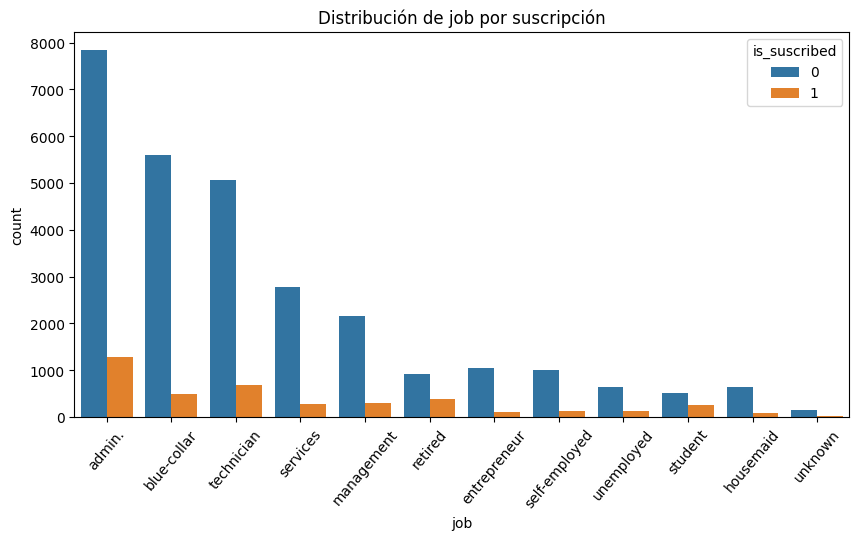

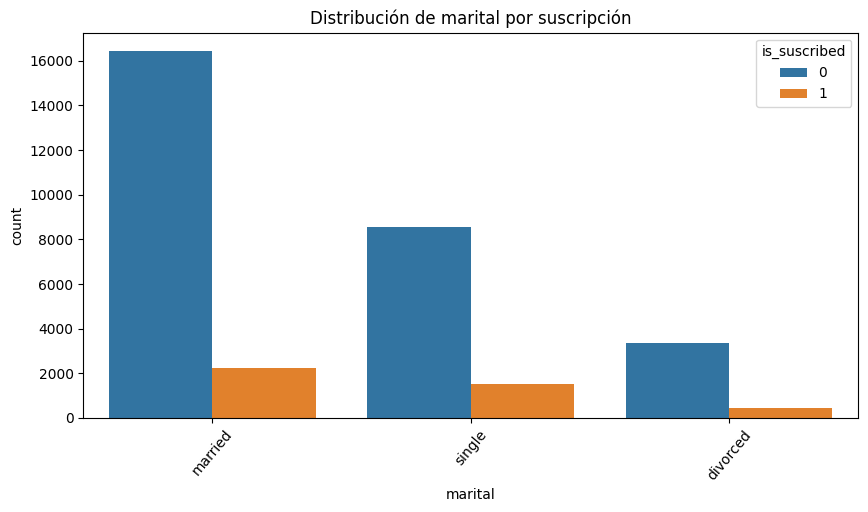

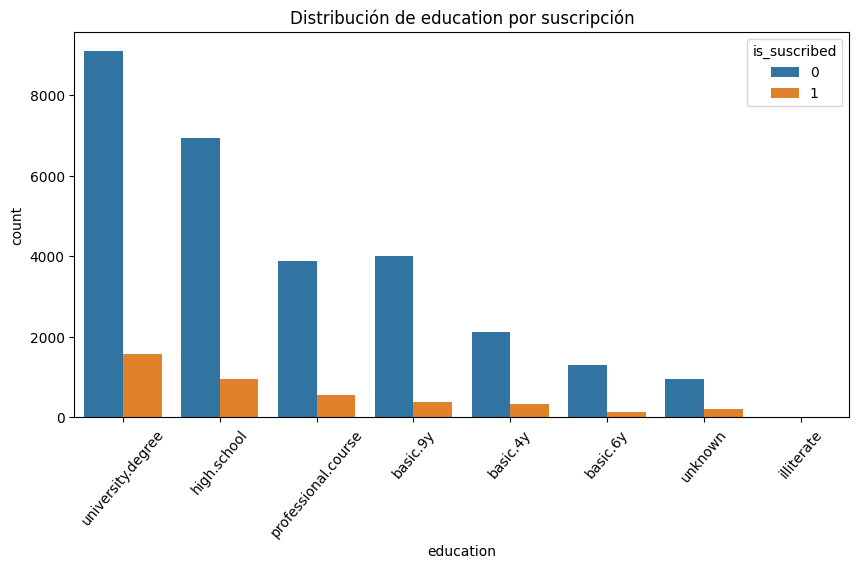

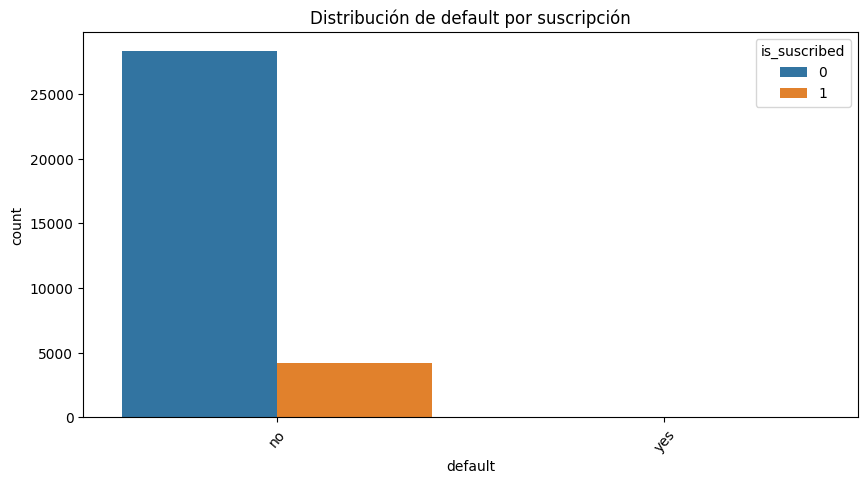

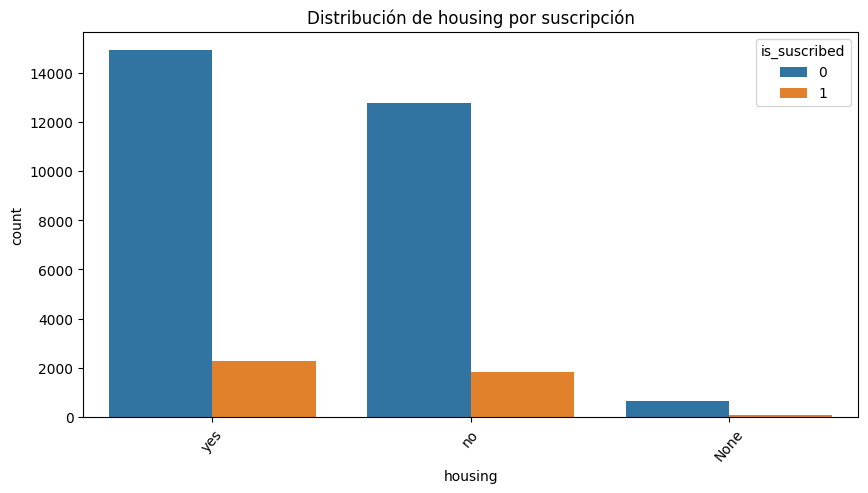

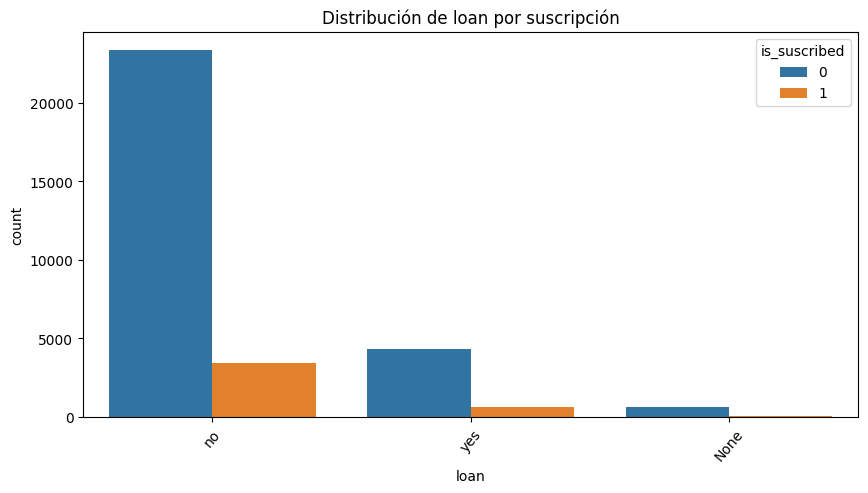

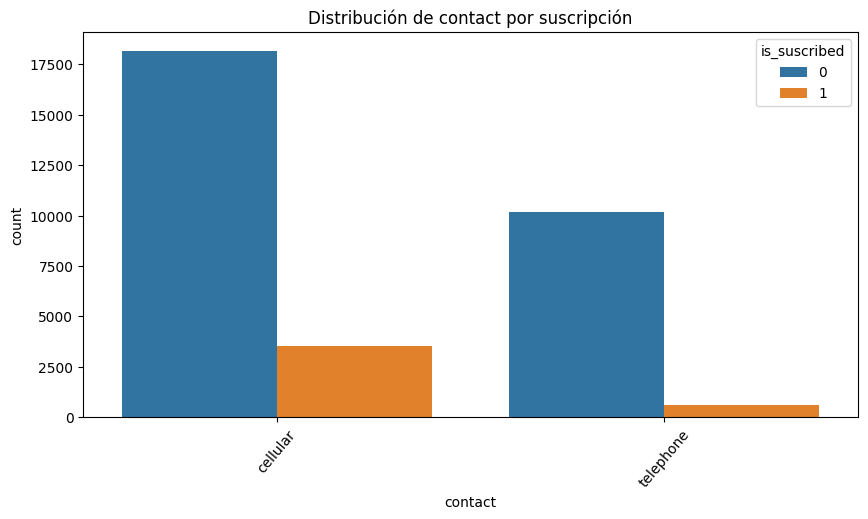

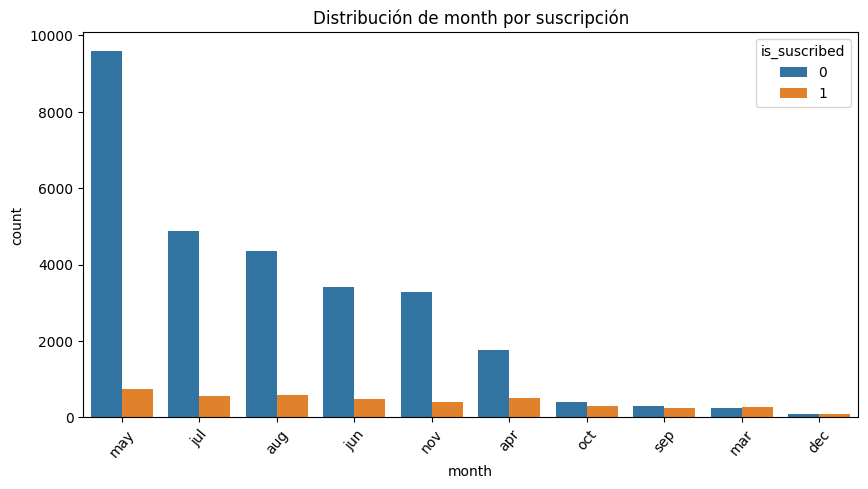

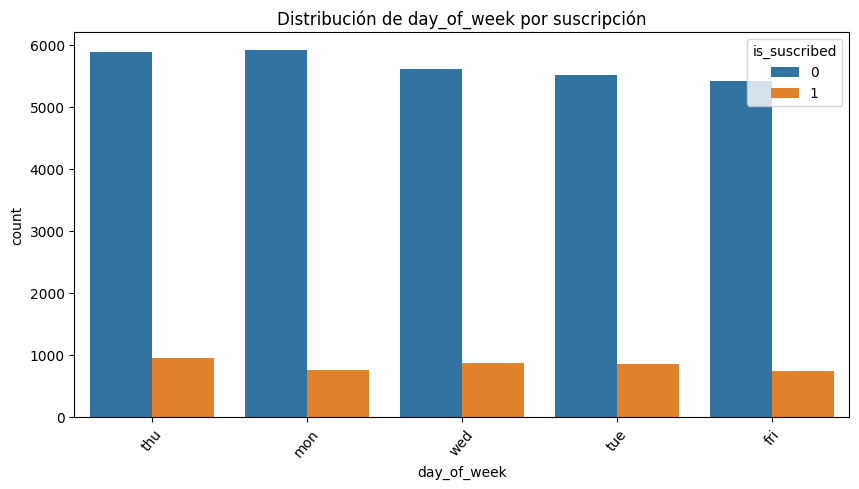

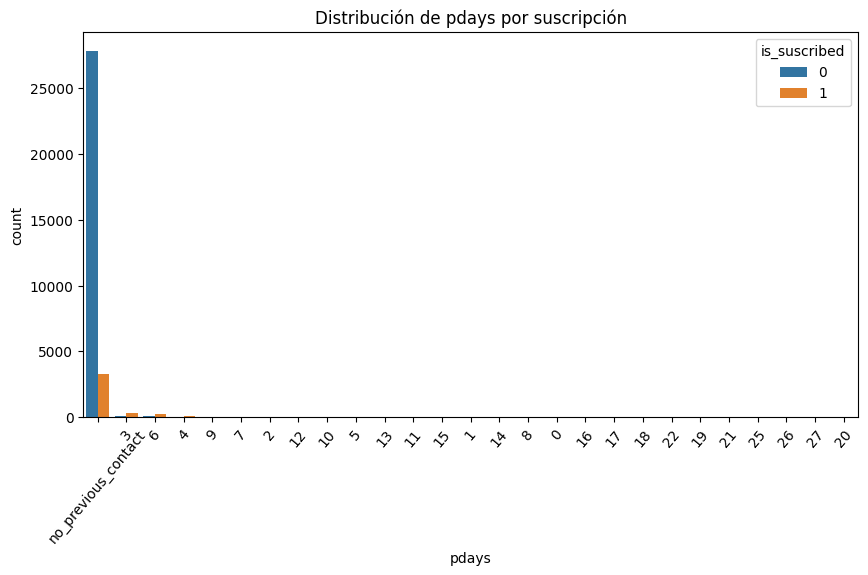

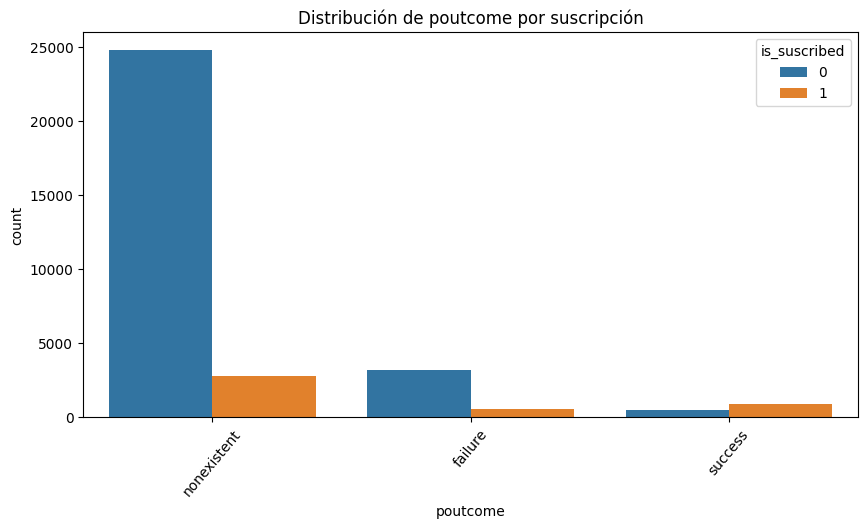

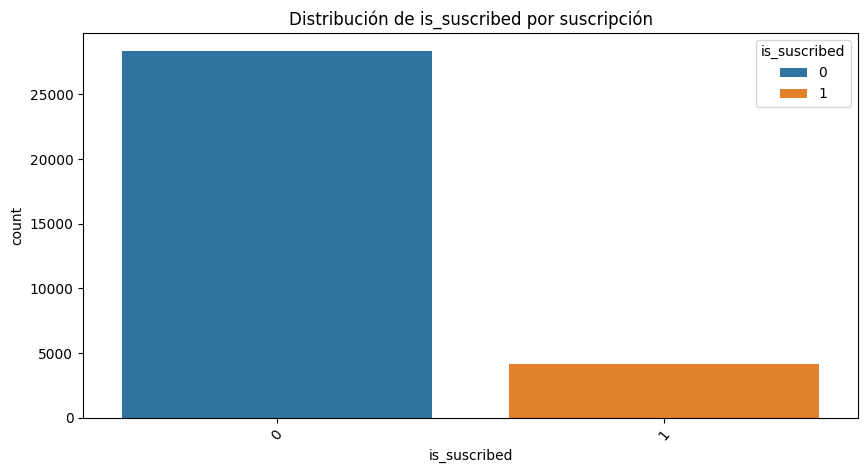

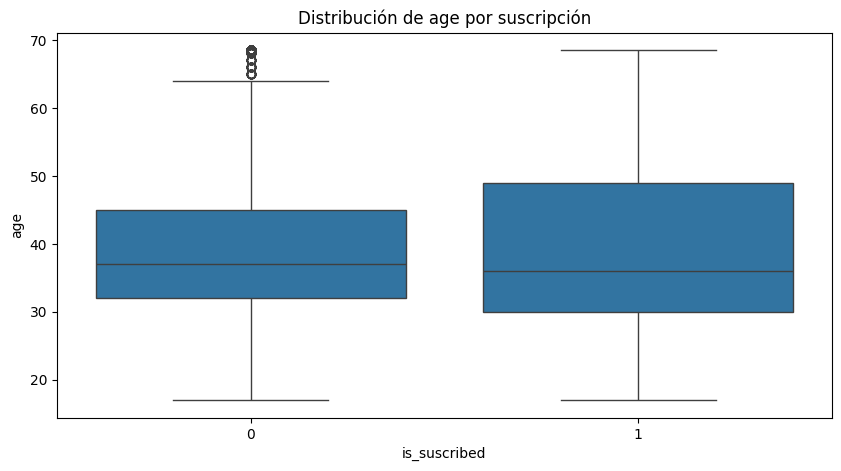

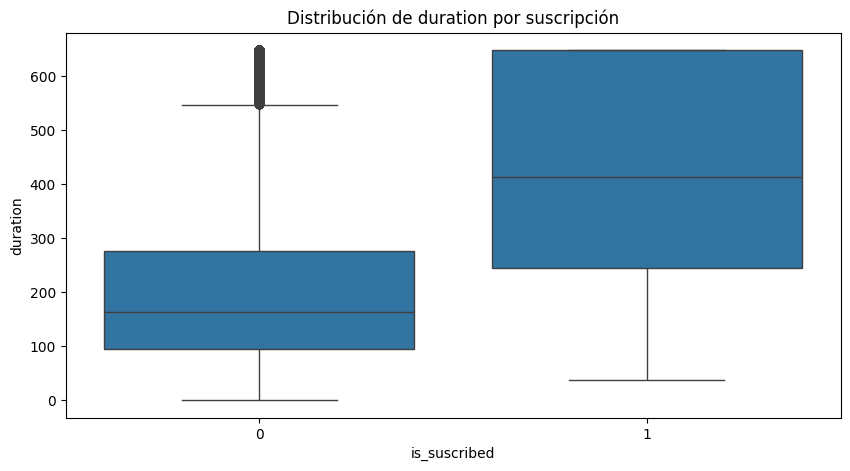

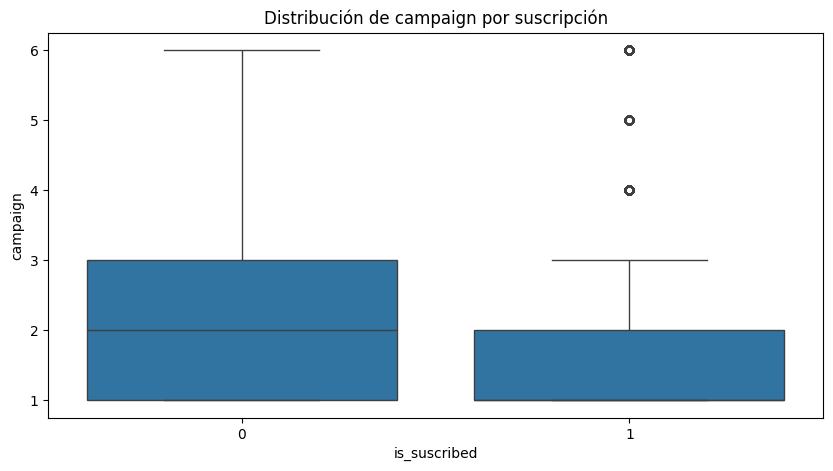

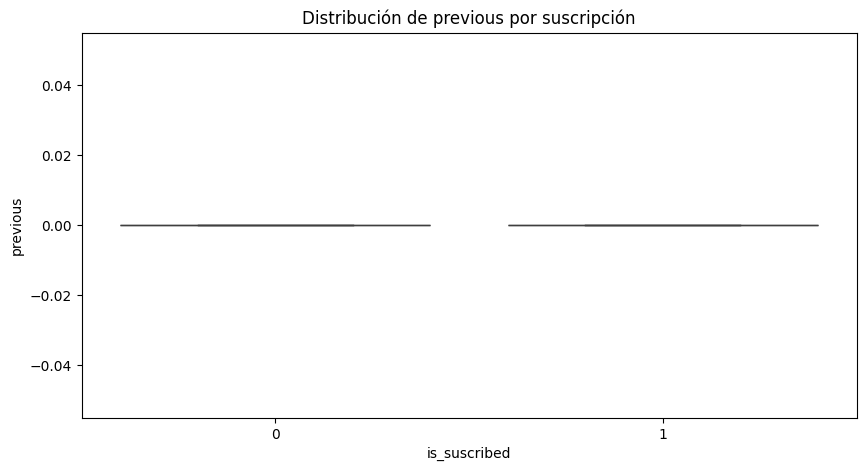

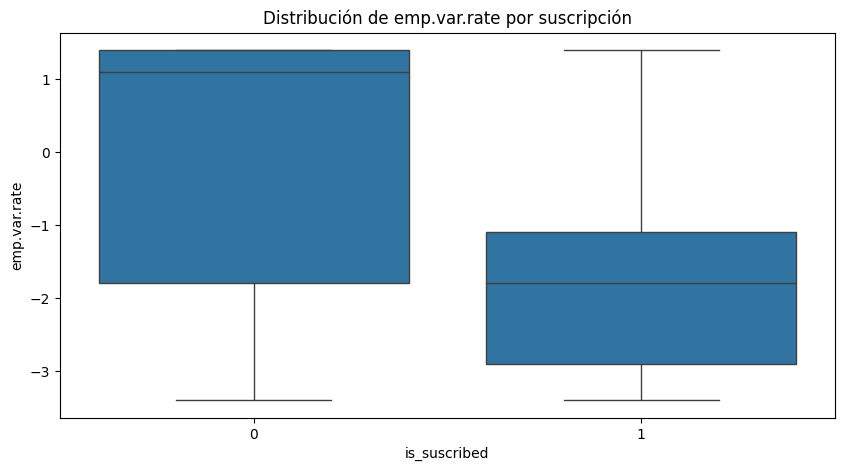

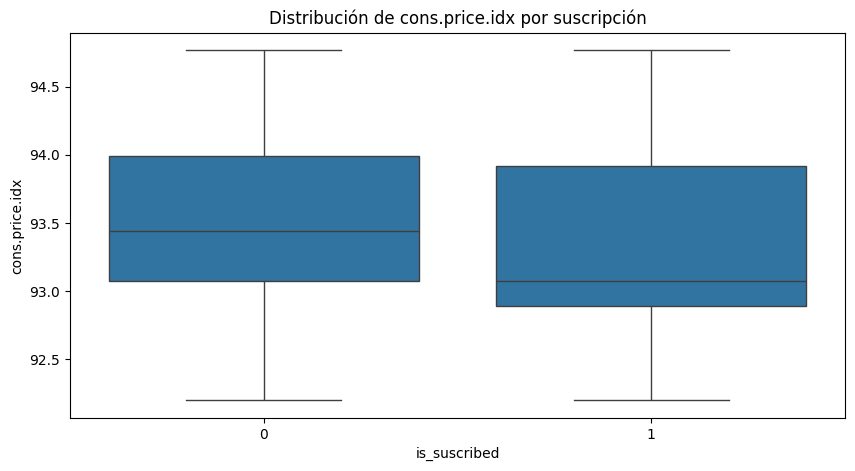

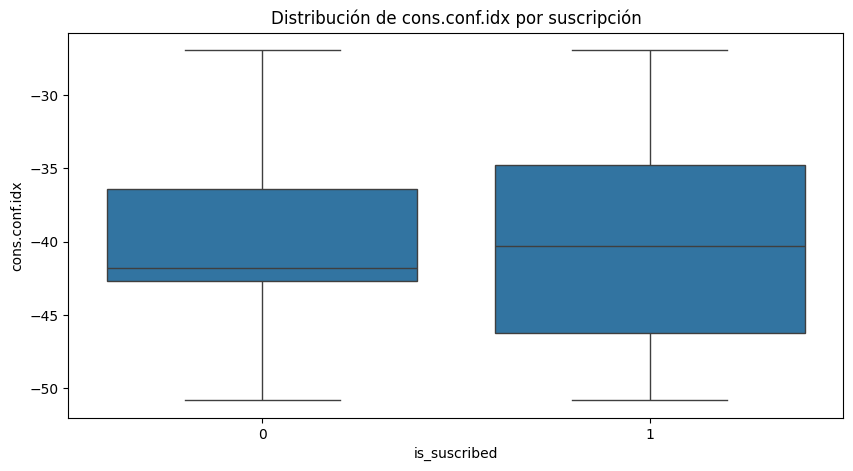

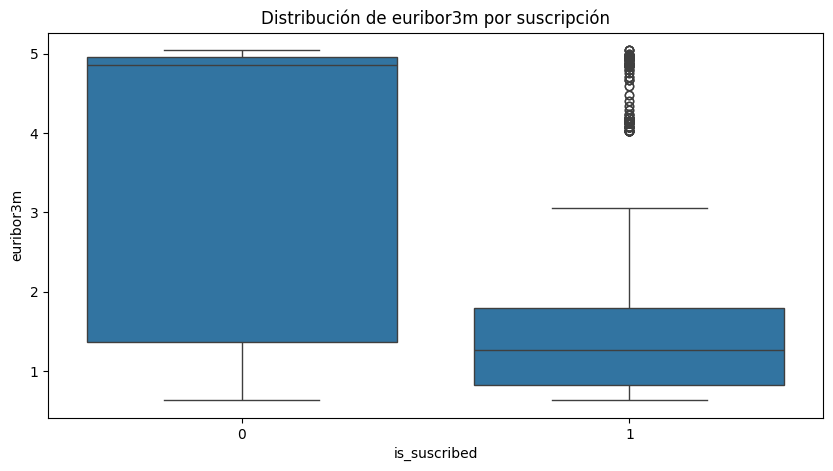

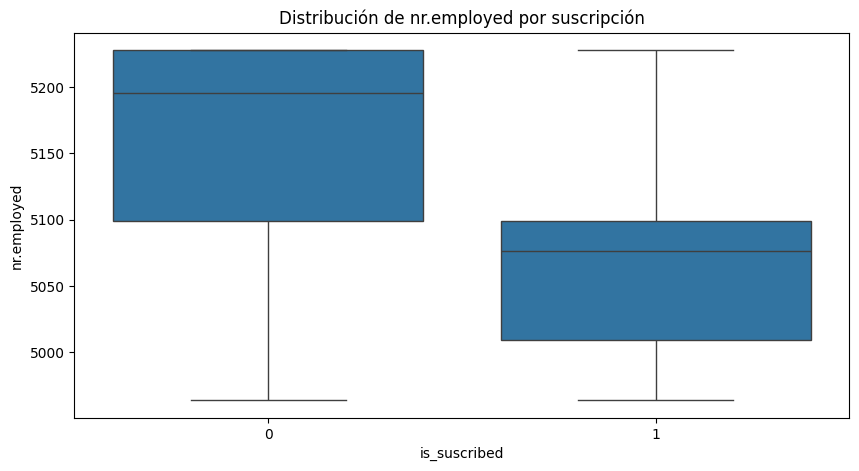

In [29]:
for col in categorical_vars: 
    plt.figure(figsize=(10, 5)) 
    sns.countplot(data=df, x=col, hue='is_suscribed', order=df[col].value_counts().index) 
    plt.title(f"Distribución de {col} por suscripción") 
    plt.xticks(rotation=50) 
    plt.show()

for col in numerical_vars: 
    plt.figure(figsize=(10, 5)) 
    sns.boxplot(data=df, x='is_suscribed', y=col) 
    plt.title(f"Distribución de {col} por suscripción") 
    plt.show()

en este caso, he realizado un analisis bivariado de las variables categóricas y las numéricas con la variable target (is_suscribed).
cabe recalcar que para entender bien la variable objetivo 'is_suscribed' el 0 corresponde a 'no suscrito' y 1 'suscrito'. Muchas de las graficas son practicamente imposibles de entender como por ejemplo la del euribor ya que hay demasiados datos.

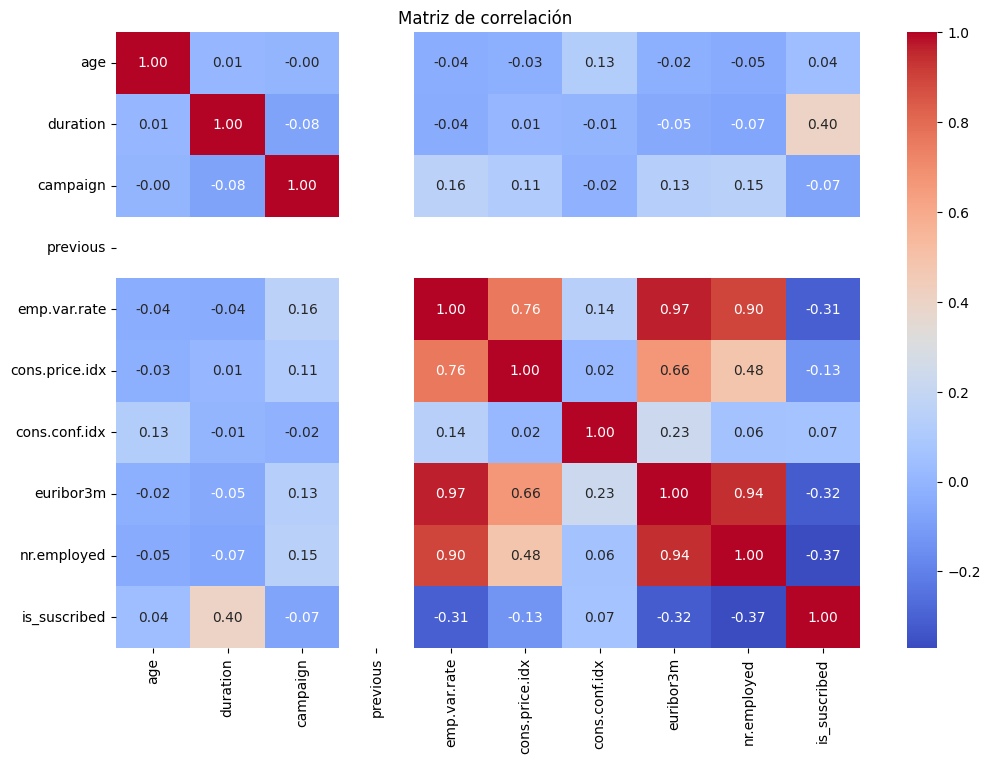

In [30]:
df['is_suscribed'] = df['is_suscribed'].astype(int)

numeric_df = df.select_dtypes(include=['number'])
correlation_matrix = numeric_df.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de correlación ")
plt.show()

Como al inicio del codigo cambié la variable is_suscribed a categorica, la he puesto numerica para incluirla en la matriz de correlacion, ya que es vital analizar su correlacion con las demas variables numericas. Antes de transformarla intenté hacer la matriz incluyendo todas las variables pero da error por lo tanto he incluido solo las variables numericas.
En este fragmento de codigo me he apoyado de la IA para utilizar el seaborn, es decir, para que la matriz de correlacion sea visualmente mas atractiva y mas facil de entender

is_suscribed    1.000000
duration        0.400783
emp.var.rate   -0.310151
euribor3m      -0.321709
nr.employed    -0.370077
Name: is_suscribed, dtype: float64


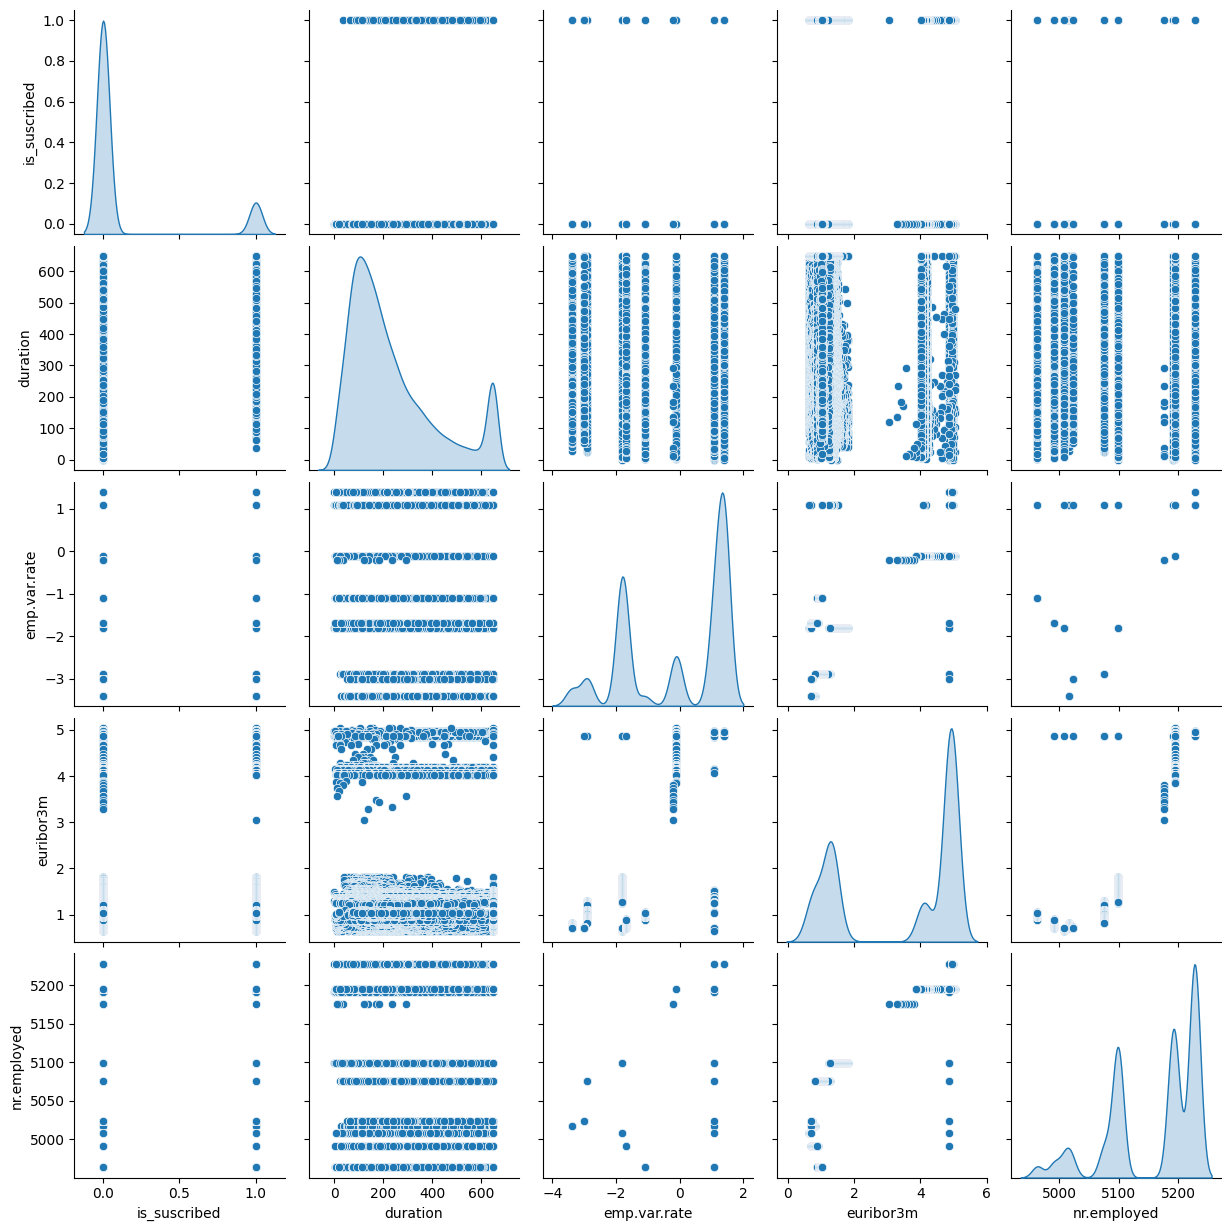

In [31]:
numeric_cols_with_target = numerical_vars.copy()  
numeric_cols_with_target.append('is_suscribed')   

corr = df[numeric_cols_with_target].corr()  
corr_target_selected = corr['is_suscribed'].sort_values(ascending=False)  
corr_target_selected = corr_target_selected[abs(corr_target_selected) > 0.15]  
print(corr_target_selected)  

numeric_cols_target = corr_target_selected.index.tolist()  

sns.pairplot(df[numeric_cols_target], diag_kind='kde')  
plt.show() 

En un inicio había realizado un análisis multivariable normal, pero había demasiadas variables las cuales no me aportaban nada de varlor, por lo tanto he usado solo aquellas con mayor correlacion. Por lo que he creado una la lista de variables numericas y he añadido la variable objetivo para despues calcular la matriz de correlacion. En las dos siguientes lineas lo que he hecho es seleccionar aquellas variables con mayor correlaciones como mencione, lo que hace la siguiente linea es filtrar aquellas variables que tengan una correlacion fuerte (>0,5) y por ultimo hago los graficos con seaborn (me he apoyado de la IA para hacer el analisis multivariable) 

Una vez que hacemos el multivariable con aquellas variables que tengan una buena correlacion con is_suscribed vemos como se nos reduce el analisis a 5 variables, trabajando de este modo con datos mucho mas utiles para nuestro EDA. La varaible con más correlacion con is_suscribed es la duracion de cada llamada

### CONCLUSIONES:

Una vez que hemos realizado todos los pasos fundamentales del EDA podemos sacar conclusiones acerca de todos los gráficos que hemos ido sacando con todos los diferentes análisis: 

La variable objetivo ‘is_suscribed’ indica que clientes han suscrito un depósito a plazo, y tras comparar quienes lo han suscrito y quienes no, vemos como la gran mayoría de ellos no tienen un depósito a plazo. 

La ocupación que cuenta con más clientes son los administradores, mientras que si nos fijamos en nivel educativo la gran mayoría tienen un grado universitario. 

La gran parte de los clientes están casados, seguidos por los solteros y finalmente los clientes que están o divorciados o viudos. 

La variable default la podemos eliminar del modelo ya que no aporta ningun tipo de valor. 

Hay más clientes que tienen un préstamo para su vivienda que no, aunque la diferencia es mínima, en cuanto al préstamo personal hay muchos más clientes que no cuentan con ello que por el contrario si tienen un préstamo personal. 

Los meses en los que más actividad hay son los próximos al verano, es decir, julio agosto, junio y en el que más actividad hay es en mayo. 

No hay ningún tipo de actividad los findes de semana, sólo de lunes a viernes. 

Pdays es una variable que no aporta valor, por lo que también se puede eliminar. 

En cuanto a las campañas de marketing, en la mayoría de los casos no se ha hecho campaña, pero si se ha hecho ha habido más fracasos que éxitos. 

La edad media del cliente está entre los 30 y los 40 años, pero se inclina mucho más hacia los 30. 

La duración de las llamadas es una variable la cual tiene una fuerte correlación con la variable objetivo (comparada con las demás variables), la duración suele ser muy corta, casi no llega ni a los dos minutos, y lo máximo han sido unos 18 minutos. 

El índice de precios del consumidor está en 94.0 

La ocupación con más suscripciones de depósitos es la de administración, aunque hay que tener en cuenta que es porque es la que más clientes tiene. Si nos queremos fijar en que ocupación hay mayor densidad de suscripción son los estudiantes. 

Lo mismo ocurre con el estado civil, aquellos que tienen más suscripciones son los casados, pero si hablamos de densidad de suscripción son los solteros. 

En cuanto al préstamo de vivienda pese a que haya más clientes que cuenten con préstamo, hay casi el mismo número de suscripciones. 

En cuanto a los meses, pese a que no haya mucha actividad en marzo, cabe recalcar que contactan más personas suscritas que no suscritas, siendo el único mes en el que esto ocurre.  

El día de la semana que interactúan más personas con suscripción a depósito es el jueves, aunque todos están muy parejos. 

En cuanto a la distribución de las campañas de marketing, la mayoría no eran exitosas, pero aquellas que si lo son tienen muchos más clientes con suscripción. 

Una vez vistas las correlaciones, aquellas variables con más relación lineal con la variable target is_suscribed son la duración de las llamadas, el Euribor, el número de empleados y la variación de empleo. 
